In [45]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler

In [46]:
reader = pd.read_csv('datasets/data_2d.csv', header=None, chunksize=10000)
df_2d = pd.concat(reader, ignore_index=True)
df_2d.drop(columns=[0], inplace=True)
df_2d.drop_duplicates(inplace=True)
df_2d.head()

,1,2
0,-0.768716,0.460860
1,2.687848,2.366961
2,-0.201379,0.470430
3,0.608496,1.225400
4,-0.082282,1.137218


In [47]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(df_2d)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_2d, kmeans.labels_))

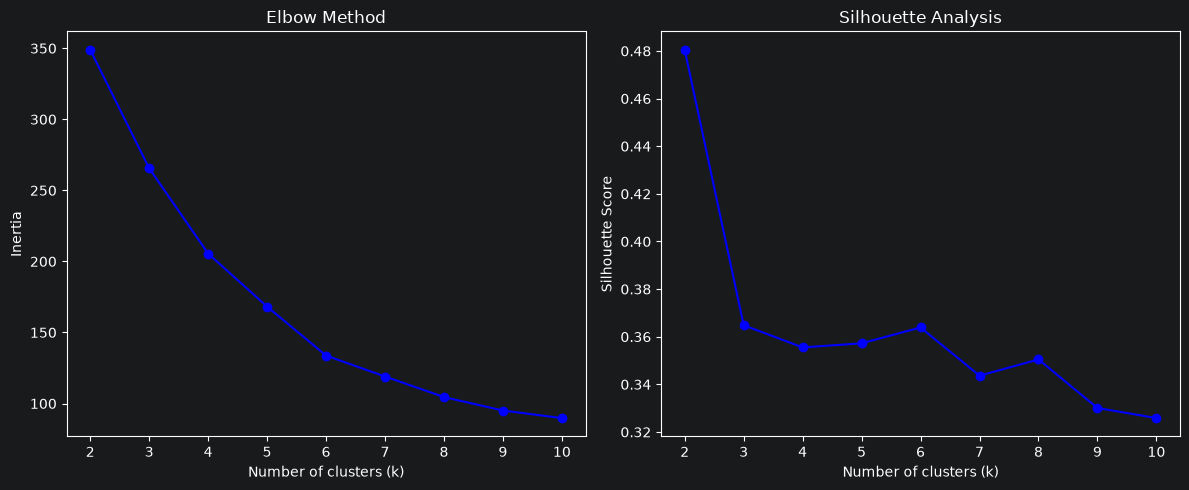

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

axes[0].plot(k_range, inertias, marker='o', color='b', linestyle='-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

axes[1].plot(k_range, silhouettes, marker='o', color='b', linestyle='-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

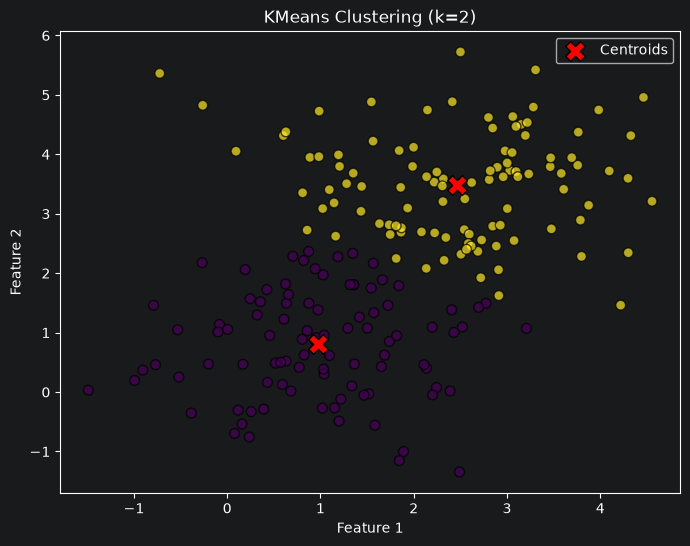

In [49]:
clusters = KMeans(n_clusters=2, random_state=42, n_init="auto").fit(df_2d)

plt.figure(figsize=(8, 6))
plt.scatter(
    df_2d[1], df_2d[2],
    c=clusters.labels_,
    cmap='viridis', edgecolor='black',
    alpha=0.7, s=50
)

plt.scatter(
    clusters.cluster_centers_[:, 0],
    clusters.cluster_centers_[:, 1],
    c='red', marker='X', s=200, edgecolor='black',
    label='Centroids'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering (k=2)')
plt.legend()
plt.show()

### Оптимальна кількість кластерів для датасету data_2d - 2 кластери

In [50]:
reader = pd.read_csv('datasets/mnist.csv', header=None, chunksize=10000)
df_mnist = pd.concat(reader, ignore_index=True)
df_mnist.drop(columns=[0], inplace=True)
df_mnist.drop_duplicates(inplace=True)
df_mnist.head()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
inertias = []
silhouettes = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(df_mnist)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_mnist, kmeans.labels_))

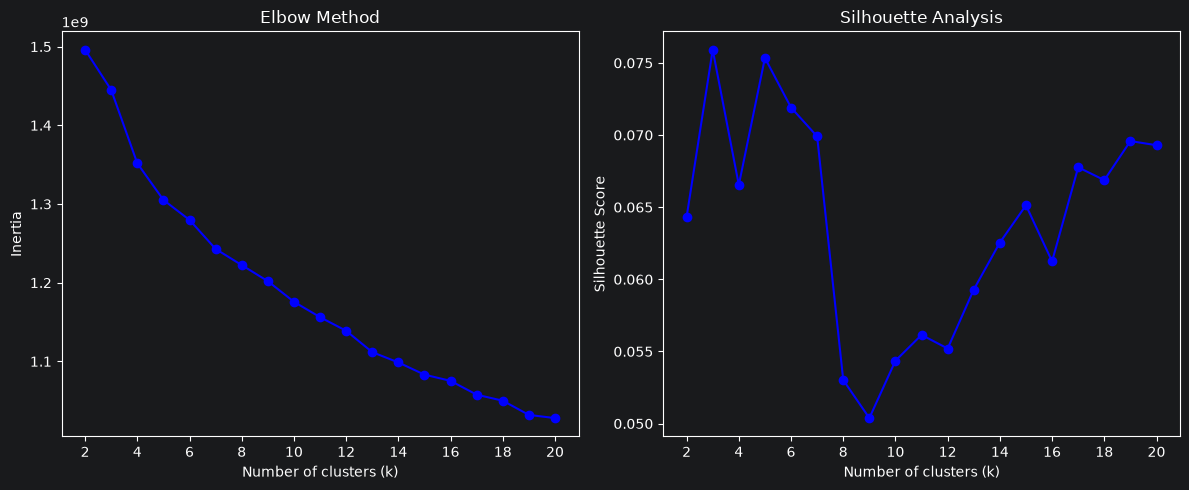

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

axes[0].plot(k_range, inertias, marker='o', color='b', linestyle='-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

axes[1].plot(k_range, silhouettes, marker='o', color='b', linestyle='-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

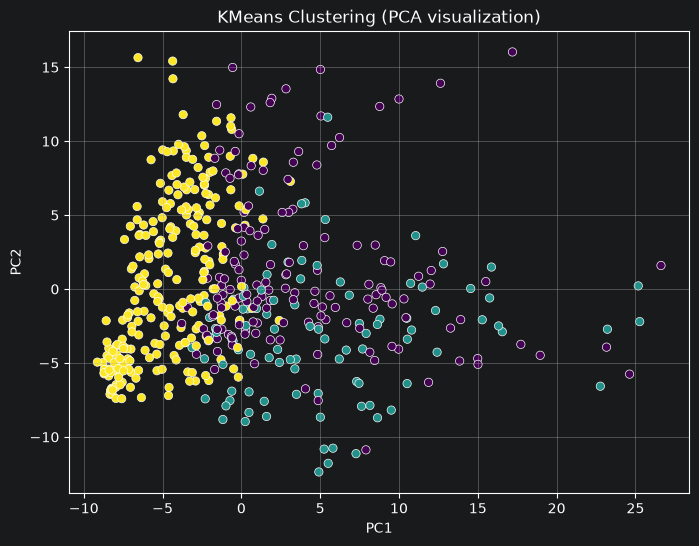

In [53]:
clusters = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(df_mnist)

scaler = StandardScaler()
scaler.fit(df_mnist)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.transform(df_mnist))


plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], c=clusters.labels_,)
plt.title('KMeans Clustering (PCA visualization)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()